# Signal Escalation Predictor

Predict the probability that a financial signal will be escalated for investigation.
Pipeline: Transactions → Features → LightGBM → Probability.
Evaluated with ROC-AUC.

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
import lightgbm as lgb
import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 200)
print("Environment ready ✅")

Environment ready ✅


## 2. Load Data

In [2]:
DATA = "data"
signals = pd.read_csv(f"{DATA}/signals.csv", parse_dates=["signal_time"])
txns    = pd.read_csv(f"{DATA}/transactions.csv", parse_dates=["txn_time"])

print("signals:", signals.shape, "| transactions:", txns.shape)
print("\n--- signals.head() ---")
display(signals.head())
print("\n--- txns.head() ---")
display(txns.head())
print("\nLabel balance:\n", signals["label"].value_counts(normalize=True))

signals: (1200, 5) | transactions: (10893, 8)

--- signals.head() ---


,signal_id,signal_time,label,signal_type,channel
0,SIG-01179,2024-09-24 20:38:55,1,counterparty_risk,branch
1,SIG-00866,2024-09-14 06:47:19,0,structuring,branch
2,SIG-00102,2024-06-20 17:13:40,0,unusual_hours,web
3,SIG-00440,2024-09-11 14:33:02,0,counterparty_risk,atm
4,SIG-00059,2024-02-01 02:41:34,1,counterparty_risk,web



--- txns.head() ---


,txn_id,signal_id,txn_time,amount,direction,txn_type,country,currency
0,TXN-00003747,SIG-00416,2024-09-22 00:16:02.826504,7230.60,in,payment,US,USD
1,TXN-00001711,SIG-00186,2024-11-15 06:39:46.712791,9567.02,out,withdrawal,US,USD
2,TXN-00006070,SIG-00681,2024-11-22 00:36:18.614719,418.90,in,deposit,US,USD
3,TXN-00003839,SIG-00427,2024-05-04 16:04:02.668828,409.23,in,card_purchase,US,USD
4,TXN-00006459,SIG-00725,2024-08-27 10:25:00.050818,2124.76,in,payment,US,USD



Label balance:
 label
0    0.646667
1    0.353333
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis

In [3]:
print("Missing values (signals):\n", signals.isna().sum())
print("\nMissing values (txns):\n",   txns.isna().sum())

txn_per_signal = txns.groupby("signal_id").size()
print("\nTransactions per signal:\n", txn_per_signal.describe())

Missing values (signals):
 signal_id      0
signal_time    0
label          0
signal_type    0
channel        0
dtype: int64

Missing values (txns):
 txn_id       0
signal_id    0
txn_time     0
amount       0
direction    0
txn_type     0
country      0
currency     0
dtype: int64

Transactions per signal:
 count    1200.000000
mean        9.077500
std         4.669546
min         3.000000
25%         6.000000
50%         8.000000
75%        12.000000
max        35.000000
dtype: float64


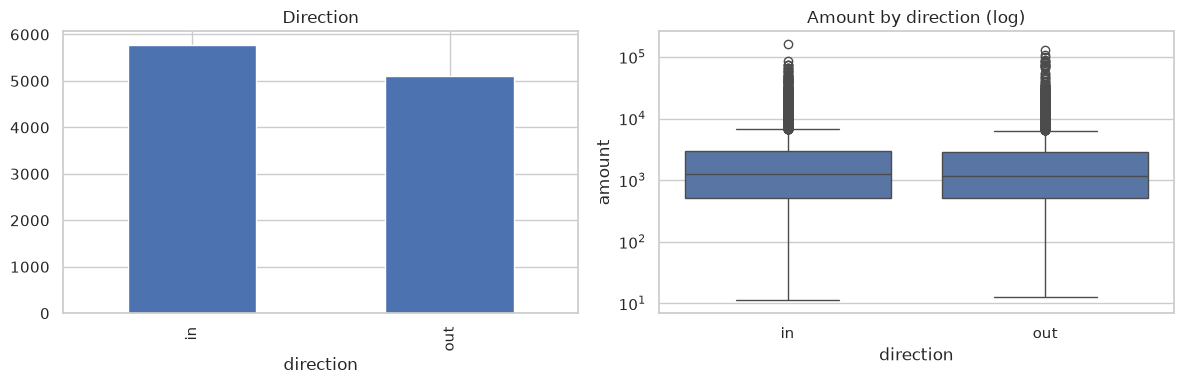

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
txns["direction"].value_counts().plot(kind="bar", ax=ax[0], title="Direction")
sns.boxplot(data=txns, x="direction", y="amount", ax=ax[1])
ax[1].set_yscale("log"); ax[1].set_title("Amount by direction (log)")
plt.tight_layout(); plt.show()

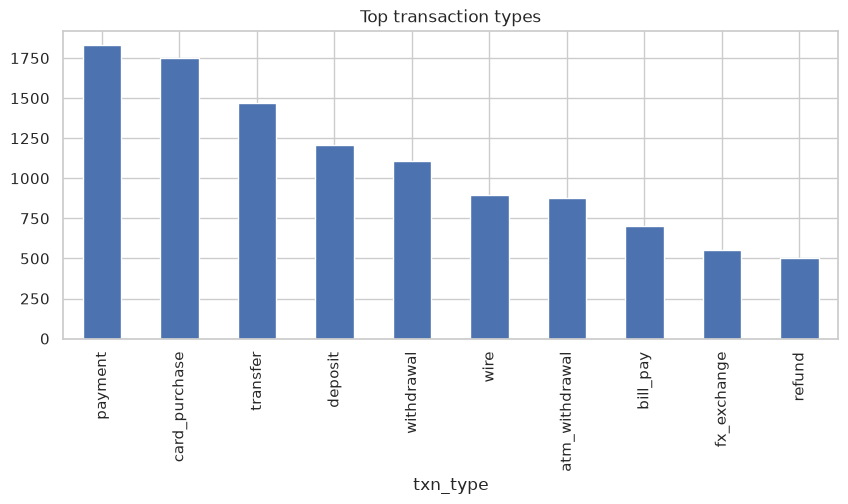

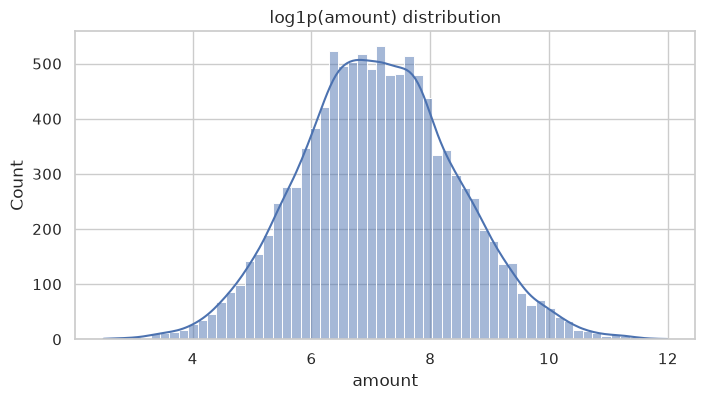

In [5]:
plt.figure(figsize=(10,4))
txns["txn_type"].value_counts().head(15).plot(kind="bar")
plt.title("Top transaction types"); plt.show()

plt.figure(figsize=(8,4))
sns.histplot(np.log1p(txns["amount"]), bins=60, kde=True)
plt.title("log1p(amount) distribution"); plt.show()

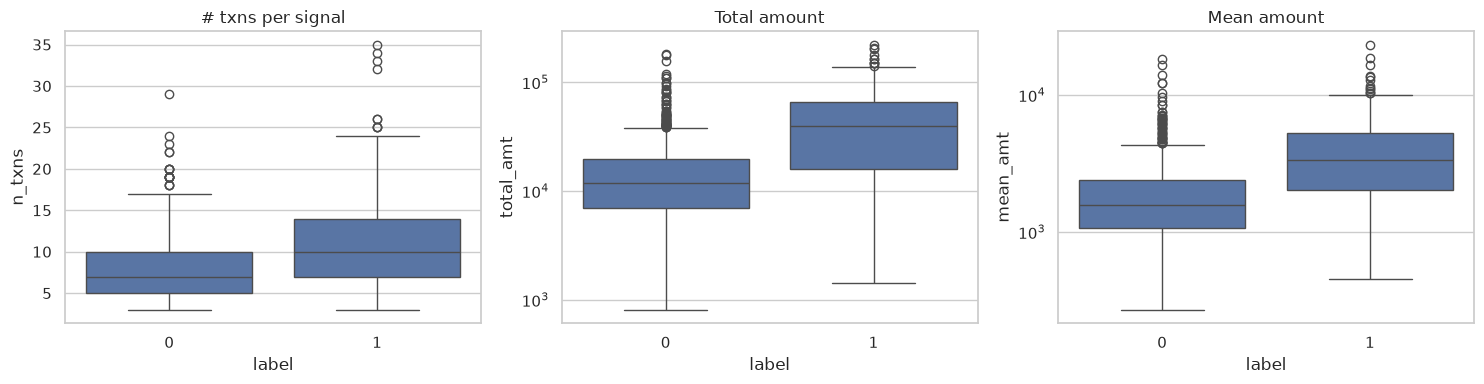

Share of incoming txns by label:
 label
0    0.500162
1    0.569951
Name: is_in, dtype: float64

International share by label:
 label
0    0.190608
1    0.261448
Name: intl, dtype: float64


In [6]:
txns_lab = txns.merge(signals[["signal_id", "label"]], on="signal_id", how="left")

agg = (txns_lab.groupby(["signal_id", "label"])
       .agg(n_txns=("txn_id", "count"),
            total_amt=("amount", "sum"),
            mean_amt=("amount", "mean"))
       .reset_index())

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=agg, x="label", y="n_txns",    ax=ax[0]); ax[0].set_title("# txns per signal")
sns.boxplot(data=agg, x="label", y="total_amt", ax=ax[1]); ax[1].set_yscale("log"); ax[1].set_title("Total amount")
sns.boxplot(data=agg, x="label", y="mean_amt",  ax=ax[2]); ax[2].set_yscale("log"); ax[2].set_title("Mean amount")
plt.tight_layout(); plt.show()

pivot = (txns_lab.assign(is_in=(txns_lab.direction.astype(str).str.lower()=="in").astype(int))
         .groupby("label")["is_in"].mean())
print("Share of incoming txns by label:\n", pivot)

if "country" in txns_lab.columns:
    home = txns_lab["country"].mode().iloc[0]
    intl = (txns_lab.assign(intl=(txns_lab.country != home).astype(int))
            .groupby("label")["intl"].mean())
    print("\nInternational share by label:\n", intl)

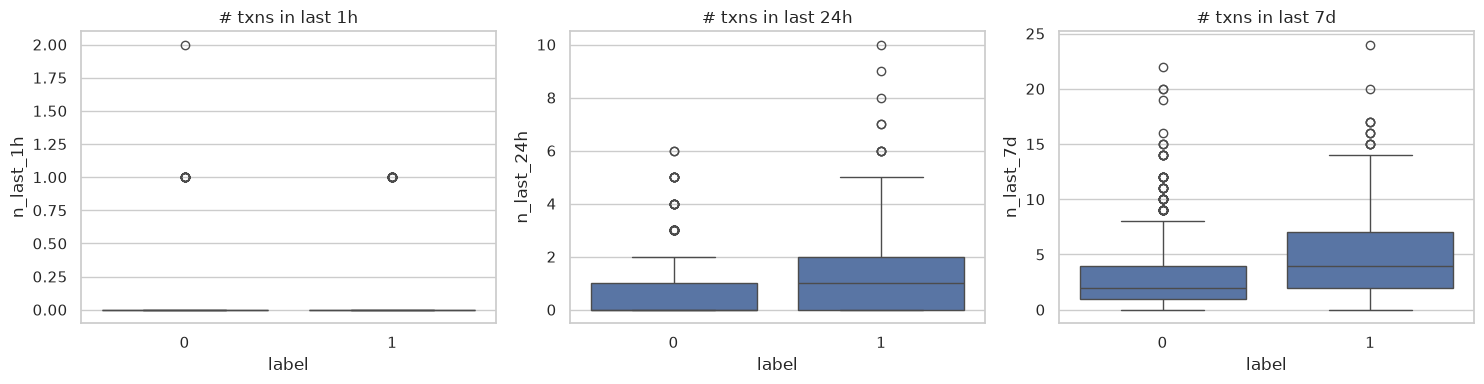

In [7]:
t = txns.merge(signals[["signal_id","signal_time","label"]], on="signal_id", how="left")
t["dt_hours"] = (t["signal_time"] - t["txn_time"]).dt.total_seconds() / 3600

windows = {"1h":1, "24h":24, "7d":24*7}
agg_win = agg.copy()
for name, h in windows.items():
    counts = (t[t.dt_hours <= h].groupby("signal_id").size()
              .rename(f"n_last_{name}").reset_index())
    agg_win = agg_win.merge(counts, on="signal_id", how="left")
agg_win = agg_win.fillna({f"n_last_{k}":0 for k in windows})

fig, ax = plt.subplots(1, 3, figsize=(15,4))
for i, k in enumerate(windows):
    sns.boxplot(data=agg_win, x="label", y=f"n_last_{k}", ax=ax[i])
    ax[i].set_title(f"# txns in last {k}")
plt.tight_layout(); plt.show()

**Patterns noticed → features we add**

- Escalated signals have MORE transactions and HIGHER total amount in the final 24h → add temporal-window aggregates.
- Higher international share → add `intl_ratio`, `n_intl`, `n_unique_ctry`.
- Different transaction type mix → add per-type ratios.
- Direction (in/out) imbalance → add `in_ratio`, `out_ratio`.

## 4. Feature Engineering — one row per signal_id

In [8]:
def build_features(signals: pd.DataFrame, txns: pd.DataFrame) -> pd.DataFrame:
    s = signals.copy()
    t = txns.copy()

    # Merge signal_time for temporal features
    t = t.merge(s[["signal_id", "signal_time"]], on="signal_id", how="left")
    t["dt_hours"] = (t["signal_time"] - t["txn_time"]).dt.total_seconds() / 3600

    # ---- Base aggregations ----
    g = t.groupby("signal_id")
    feats = g.agg(
        n_txns         = ("txn_id",  "count"),
        total_amount   = ("amount",  "sum"),
        mean_amount    = ("amount",  "mean"),
        median_amount  = ("amount",  "median"),
        std_amount     = ("amount",  "std"),
        max_amount     = ("amount",  "max"),
        min_amount     = ("amount",  "min"),
        sum_log_amount = ("amount",  lambda x: np.log1p(x).sum()),
        n_unique_types = ("txn_type","nunique"),
        n_unique_ctry  = ("country", "nunique"),
    ).reset_index()

    # ---- Direction shares ----
    t["is_in"] = (t["direction"].astype(str).str.lower() == "in").astype(int)
    dir_feats = g["is_in"].agg(["mean", "sum"]).rename(
        columns={"mean":"in_ratio", "sum":"n_in"}).reset_index()
    feats = feats.merge(dir_feats, on="signal_id", how="left")
    feats["n_out"]     = feats["n_txns"] - feats["n_in"]
    feats["out_ratio"] = 1 - feats["in_ratio"]

    # ---- International share ----
    home = t["country"].mode().iloc[0]
    t["is_intl"] = (t["country"] != home).astype(int)
    intl = g["is_intl"].agg(["mean","sum"]).rename(
        columns={"mean":"intl_ratio","sum":"n_intl"}).reset_index()
    feats = feats.merge(intl, on="signal_id", how="left")

    # ---- Transaction type distribution (top-10 ratios) ----
    top_types = t["txn_type"].value_counts().head(10).index.tolist()
    for tt in top_types:
        col = f"type_{str(tt).replace(' ','_')}_ratio"
        r = (t.assign(_hits=(t.txn_type==tt).astype(int))
               .groupby("signal_id")["_hits"].mean()
               .rename(col).reset_index())
        feats = feats.merge(r, on="signal_id", how="left")

    # ---- Temporal windows ----
    for name, h in {"1h":1, "6h":6, "24h":24, "7d":168}.items():
        sub = t[t["dt_hours"].between(0, h)]
        cnt = sub.groupby("signal_id").size().rename(f"n_last_{name}").reset_index()
        amt = sub.groupby("signal_id")["amount"].sum().rename(f"amt_last_{name}").reset_index()
        feats = feats.merge(cnt, on="signal_id", how="left") \
                     .merge(amt, on="signal_id", how="left")

    # ---- Time deltas ----
    last_dt  = t.sort_values("dt_hours").groupby("signal_id")["dt_hours"].min() \
                .rename("hours_since_last_txn").reset_index()
    first_dt = t.sort_values("dt_hours").groupby("signal_id")["dt_hours"].max() \
                .rename("hours_since_first_txn").reset_index()
    feats = feats.merge(last_dt,  on="signal_id", how="left") \
                 .merge(first_dt, on="signal_id", how="left")

    # ---- Velocity / ratios ----
    feats["txn_velocity_24h"] = feats["n_last_24h"] / feats["n_txns"].clip(lower=1)
    feats["amt_velocity_24h"] = feats["amt_last_24h"] / feats["total_amount"].clip(lower=1)
    feats["log_total_amount"] = np.log1p(feats["total_amount"])
    feats["amt_per_txn"]      = feats["total_amount"] / feats["n_txns"].clip(lower=1)
    feats["span_hours"]       = feats["hours_since_first_txn"] - feats["hours_since_last_txn"]

    # Fill NaNs from signals with no transactions
    fill0 = [c for c in feats.columns if c != "signal_id"]
    feats[fill0] = feats[fill0].fillna(0)

    # ---- Signal-level metadata ----
    meta_cols = [c for c in ["signal_id","signal_type","channel"] if c in s.columns]
    out = s[meta_cols].merge(feats, on="signal_id", how="left")
    out[fill0] = out[fill0].fillna(0)

    cat_cols = [c for c in ["signal_type","channel"] if c in out.columns]
    if cat_cols:
        out = pd.get_dummies(out, columns=cat_cols, dummy_na=False)

    return out


X_all = build_features(signals, txns)
X_all = X_all.merge(signals[["signal_id","label"]], on="signal_id", how="left")
print("Feature matrix:", X_all.shape)
X_all.head()

Feature matrix: (1200, 55)


,signal_id,n_txns,total_amount,mean_amount,median_amount,std_amount,max_amount,min_amount,sum_log_amount,n_unique_types,n_unique_ctry,in_ratio,n_in,n_out,out_ratio,intl_ratio,n_intl,type_payment_ratio,type_card_purchase_ratio,type_transfer_ratio,type_deposit_ratio,type_withdrawal_ratio,type_wire_ratio,type_atm_withdrawal_ratio,type_bill_pay_ratio,type_fx_exchange_ratio,type_refund_ratio,n_last_1h,amt_last_1h,n_last_6h,amt_last_6h,n_last_24h,amt_last_24h,n_last_7d,amt_last_7d,hours_since_last_txn,hours_since_first_txn,txn_velocity_24h,amt_velocity_24h,log_total_amount,amt_per_txn,span_hours,signal_type_amount_spike,signal_type_counterparty_risk,signal_type_device_change,signal_type_geo_anomaly,signal_type_structuring,signal_type_unusual_hours,signal_type_velocity,channel_api,channel_atm,channel_branch,channel_mobile,channel_web,label
0,SIG-01179,17,46489.40,2734.670588,1554.970,3005.118910,11096.82,173.73,126.155191,7,5,0.529412,9,8,0.470588,0.294118,5,0.176471,0.000000,0.235294,0.117647,0.235294,0.117647,0.000000,0.000000,0.058824,0.058824,0.0,0.0,2.0,1769.56,6.0,5249.19,16.0,45884.99,1.940105,178.403642,0.352941,0.112912,10.747001,2734.670588,176.463537,False,True,False,False,False,False,False,False,False,True,False,False,1
1,SIG-00866,12,9825.98,818.831667,692.550,678.380907,2699.39,15.41,75.413318,9,4,0.500000,6,6,0.500000,0.250000,3,0.083333,0.083333,0.166667,0.166667,0.083333,0.000000,0.166667,0.083333,0.083333,0.083333,0.0,0.0,0.0,0.00,0.0,0.00,1.0,582.49,85.364444,975.139190,0.000000,0.000000,9.192887,818.831667,889.774746,False,False,False,False,True,False,False,False,False,True,False,False,0
2,SIG-00102,10,12192.53,1219.253000,755.690,1295.412373,3803.72,123.53,65.233878,5,3,0.600000,6,4,0.400000,0.300000,3,0.400000,0.200000,0.000000,0.100000,0.200000,0.000000,0.100000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.00,1.0,906.47,10.0,12192.53,18.374104,146.337465,0.100000,0.074346,9.408661,1219.253000,127.963362,False,False,False,False,False,True,False,False,False,False,False,True,0
3,SIG-00440,7,19135.14,2733.591429,1838.610,3753.515752,11128.16,616.17,51.747123,6,1,0.571429,4,3,0.428571,0.000000,0,0.285714,0.142857,0.142857,0.000000,0.000000,0.000000,0.142857,0.000000,0.142857,0.142857,0.0,0.0,0.0,0.00,0.0,0.00,3.0,3345.07,75.332463,289.101378,0.000000,0.000000,9.859334,2733.591429,213.768916,False,True,False,False,False,False,False,False,True,False,False,False,0
4,SIG-00059,12,42331.35,3527.612500,2317.045,4138.372449,12205.02,251.92,90.374407,7,4,0.583333,7,5,0.416667,0.416667,5,0.000000,0.416667,0.083333,0.166667,0.083333,0.083333,0.000000,0.000000,0.083333,0.083333,0.0,0.0,0.0,0.00,1.0,2342.53,4.0,15857.47,15.195633,652.733911,0.083333,0.055338,10.653307,3527.612500,637.538278,False,True,False,False,False,False,False,False,False,False,False,True,1


## 5. Training — Stratified 5-Fold Cross-Validation

In [9]:
FEATURES = [c for c in X_all.columns if c not in ("signal_id", "label")]
X = X_all[FEATURES].astype(float).values
y = X_all["label"].astype(int).values

print(f"Features: {len(FEATURES)} | Positives: {y.sum()} / {len(y)}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof = np.zeros(len(y))
models = []

params = dict(
    objective="binary",
    metric="auc",
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    reg_alpha=0.1,
    reg_lambda=0.1,
    n_estimators=2000,
    random_state=RANDOM_STATE,
)

for fold, (tr, va) in enumerate(skf.split(X, y), 1):
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X[tr], y[tr],
        eval_set=[(X[va], y[va])],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )
    p = model.predict_proba(X[va])[:, 1]
    oof[va] = p
    auc = roc_auc_score(y[va], p)
    print(f"Fold {fold}  AUC = {auc:.4f}  (best_iter={model.best_iteration_})")
    models.append(model)

print(f"\n>>> OOF ROC-AUC: {roc_auc_score(y, oof):.4f}")

Features: 53 | Positives: 424 / 1200
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 339, number of negative: 621
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000511 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4435
[L

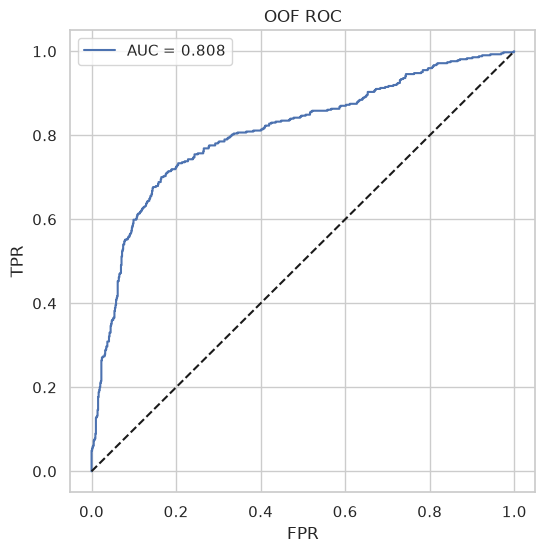

In [10]:
fpr, tpr, _ = roc_curve(y, oof)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y, oof):.3f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.title("OOF ROC")
plt.show()

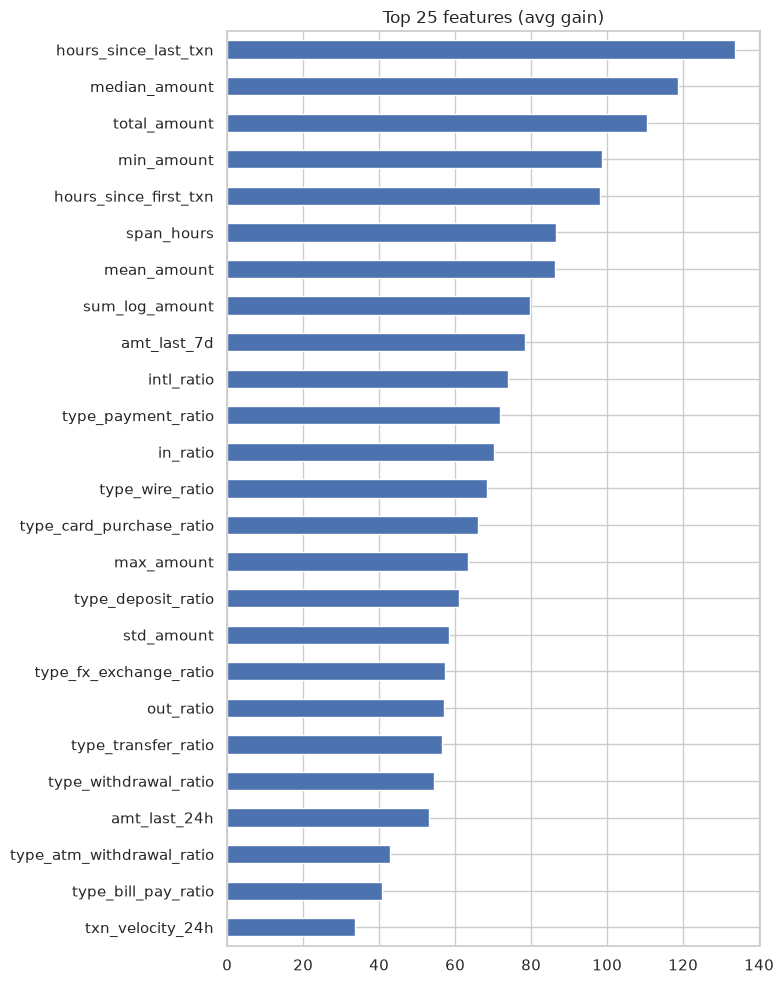

hours_since_last_txn         133.6
median_amount                118.6
total_amount                 110.4
min_amount                    98.6
hours_since_first_txn         98.2
span_hours                    86.4
mean_amount                   86.2
sum_log_amount                79.8
amt_last_7d                   78.4
intl_ratio                    74.0
type_payment_ratio            71.8
in_ratio                      70.2
type_wire_ratio               68.4
type_card_purchase_ratio      66.0
max_amount                    63.4
type_deposit_ratio            61.0
std_amount                    58.4
type_fx_exchange_ratio        57.2
out_ratio                     57.0
type_transfer_ratio           56.6
type_withdrawal_ratio         54.4
amt_last_24h                  53.0
type_atm_withdrawal_ratio     42.8
type_bill_pay_ratio           40.8
txn_velocity_24h              33.6
dtype: float64

In [11]:
imp = pd.Series(np.mean([m.feature_importances_ for m in models], axis=0),
                index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(8,10))
imp.head(25).iloc[::-1].plot(kind="barh")
plt.title("Top 25 features (avg gain)"); plt.tight_layout(); plt.show()
display(imp.head(25))

## 6. Train Final Model on 100% of Data

In [12]:
final = lgb.LGBMClassifier(**{**params, "n_estimators": 600})
final.fit(X, y)

os.makedirs("models", exist_ok=True)
joblib.dump({"model": final, "features": FEATURES}, "models/lgbm_model.pkl")
print("Saved models/lgbm_model.pkl")

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 424, number of negative: 776
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000419 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4572
[LightGBM] [Info] Number of data points

## 7. Predict Probabilities for Signals

In [13]:
def predict_proba(signals_new: pd.DataFrame, txns_new: pd.DataFrame) -> pd.DataFrame:
    """Return DataFrame with signal_id and escalation probability."""
    art = joblib.load("models/lgbm_model.pkl")
    feat_df = build_features(signals_new, txns_new)
    for c in art["features"]:
        if c not in feat_df.columns:
            feat_df[c] = 0.0
    Xnew = feat_df[art["features"]].astype(float).values
    proba = art["model"].predict_proba(Xnew)[:, 1]
    return pd.DataFrame({"signal_id": feat_df["signal_id"],
                         "escalation_probability": proba})


preds = predict_proba(signals, txns)
preds.to_csv("predictions.csv", index=False)
print("Wrote predictions.csv")
preds.head(20)

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Wrote predictions.csv


,signal_id,escalation_probability
0,SIG-01179,0.997338
1,SIG-00866,0.006630
2,SIG-00102,0.004746
3,SIG-00440,0.004208
4,SIG-00059,0.996721
5,SIG-01121,0.001175
6,SIG-00324,0.961471
7,SIG-00975,0.994430
8,SIG-00412,0.024231
9,SIG-00856,0.989267


In [14]:
print("Mean predicted probability :", preds["escalation_probability"].mean())
print("Min / Max                  :",
      preds["escalation_probability"].min(),
      preds["escalation_probability"].max())

Mean predicted probability : 0.35321677203359475
Min / Max                  : 0.00027390856394011857 0.9999455170426527


In [15]:
# === Export out-of-fold predictions for the web app ===
import pandas as pd

oof_df = pd.DataFrame({
    "signal_id": X_all["signal_id"].values,
    "escalation_probability": oof,
})
oof_df.to_csv("oof_predictions.csv", index=False)

print(f"✅ Wrote oof_predictions.csv ({len(oof_df)} rows)")
print(f"   These are HONEST scores — every signal scored by a model that never saw it.")
print(f"   OOF ROC-AUC: {roc_auc_score(y, oof):.4f}")

✅ Wrote oof_predictions.csv (1200 rows)
   These are HONEST scores — every signal scored by a model that never saw it.
   OOF ROC-AUC: 0.8077
